In [45]:
from matplotlib import cm
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import astropy.units as u
import numpy as np
import pandas as pd

In [3]:
def draw_sun(scale=1):
    theta_sun, phi_sun = np.mgrid[0:np.pi:100j, 0:2*np.pi:100j]
    xsun = np.sin(theta_sun)*np.cos(phi_sun)*scale
    ysun = np.sin(theta_sun)*np.sin(phi_sun)*scale
    zsun = np.cos(theta_sun)*scale
    return (xsun, ysun, zsun)

In [9]:
df = pd.read_csv('./test_1/theta_surface1.csv', delimiter=' ')
df.head()

,6.262049836153583726e+01,6.262049836153583726e+01.1,6.262049836153583726e+01.2,6.262049836153583726e+01.3,6.262049836153583726e+01.4,6.262049836153583726e+01.5,6.262049836153583726e+01.6,6.262049836153583726e+01.7,6.262049836153583726e+01.8,6.262049836153583726e+01.9,...,6.262049836153583726e+01.40,6.262049836153583726e+01.41,6.262049836153583726e+01.42,6.262049836153583726e+01.43,6.262049836153583726e+01.44,6.262049836153583726e+01.45,6.262049836153583726e+01.46,6.262049836153583726e+01.47,6.262049836153583726e+01.48,6.262049836153583726e+01.49
0,46.339816,50.510156,50.116996,49.693249,49.245342,48.780188,48.305110,47.827742,47.355927,46.897595,...,65.377846,65.672776,47.985016,47.905060,47.769029,47.578801,47.337021,47.047077,46.713078,46.339816
1,48.555593,47.769468,46.924789,46.033104,50.409907,49.494595,48.553512,47.601071,46.652486,45.723616,...,51.670268,51.735839,51.692801,51.541670,51.284255,50.923656,50.464245,49.911652,49.272742,48.555593
2,50.904058,49.767044,48.539773,47.237257,40.395116,42.300575,40.879263,39.481300,38.131923,47.185344,...,54.219149,52.918246,52.611437,52.157182,51.560257,50.826984,49.965203,52.855032,51.937359,50.904058
3,48.676950,45.933605,44.153646,42.313135,40.435434,42.438569,40.549791,38.673396,36.841578,47.424963,...,57.691344,54.581679,56.205600,55.629357,54.871495,53.939433,52.842315,51.590954,50.197803,48.676950
4,45.876127,43.697440,45.310846,43.065088,40.758125,38.417811,40.501858,38.158104,35.843998,47.884151,...,56.540620,55.741389,54.965622,56.647044,55.425835,54.014196,55.787788,54.289443,52.618661,45.876127


In [10]:
df.shape

(49, 50)

In [44]:
theta = df.values
theta.shape

(49, 50)

In [15]:
xarr = np.load('./test_1/xarray.npy')
yarr = np.load('./test_1/yarray.npy')
zarr = np.load('./test_1/zarray.npy')

In [17]:
print('x_array:', xarr.shape, type(xarr))
print('y_array:', yarr.shape, type(yarr))
print('z_array:', zarr.shape, type(zarr))

x_array: (50, 50) <class 'numpy.ndarray'>
y_array: (50, 50) <class 'numpy.ndarray'>
z_array: (50, 50) <class 'numpy.ndarray'>


In [24]:
xsun, ysun, zsun = draw_sun()

/tmp/ipykernel_3325713/4264213094.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('viridis')(norm(theta))


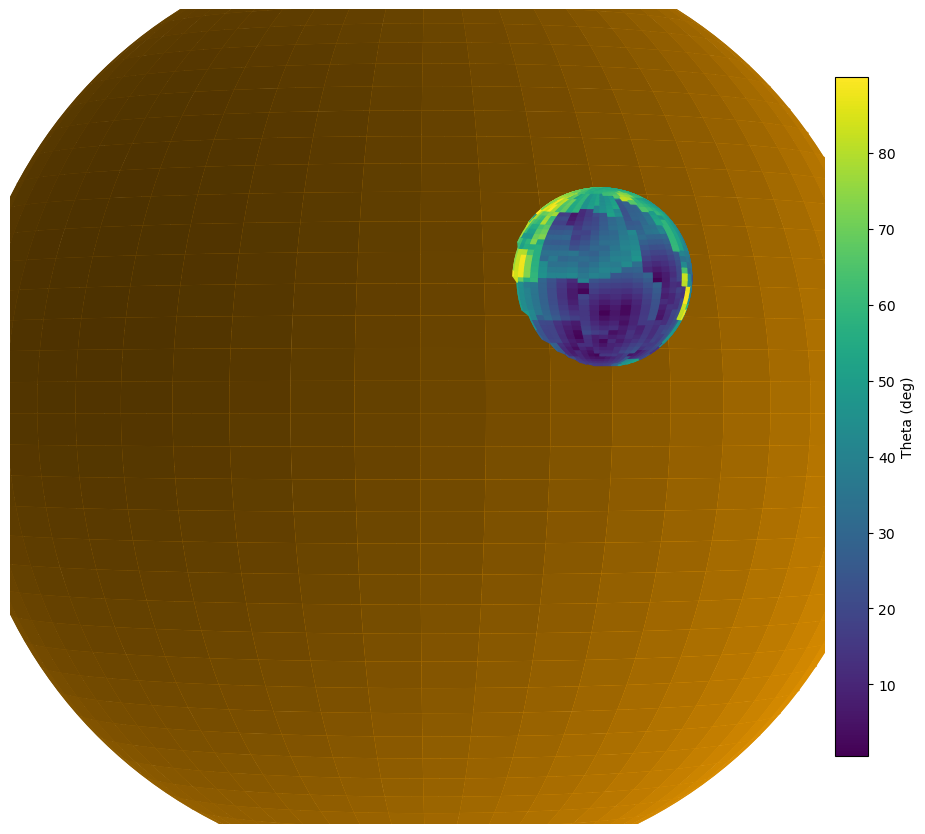

In [79]:
from matplotlib.colors import Normalize


fig = plt.figure(figsize=[10,10])
ax = fig.add_subplot(projection='3d', computed_zorder=False)
ax.plot_surface(xsun, ysun, zsun, color='orange')

norm = Normalize(vmin=np.nanmin(theta), vmax=np.nanmax(theta))
colors = cm.get_cmap('viridis')(norm(theta))

shock = ax.plot_surface(xarr, yarr, zarr,
                        facecolors=colors,
                        shade=False
                       )

mappable = cm.ScalarMappable(norm=norm, cmap='viridis')
mappable.set_array([])
cbar = plt.colorbar(mappable, ax=ax, pad=0.01, shrink=0.7)
cbar.set_label('Theta (deg)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
limit = 0.5
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)
ax.set_box_aspect([limit, limit, limit])
ax.view_init(elev=0, azim=-90)
fig.tight_layout()
plt.show()

/tmp/ipykernel_3325713/844452848.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('viridis')(norm(theta))


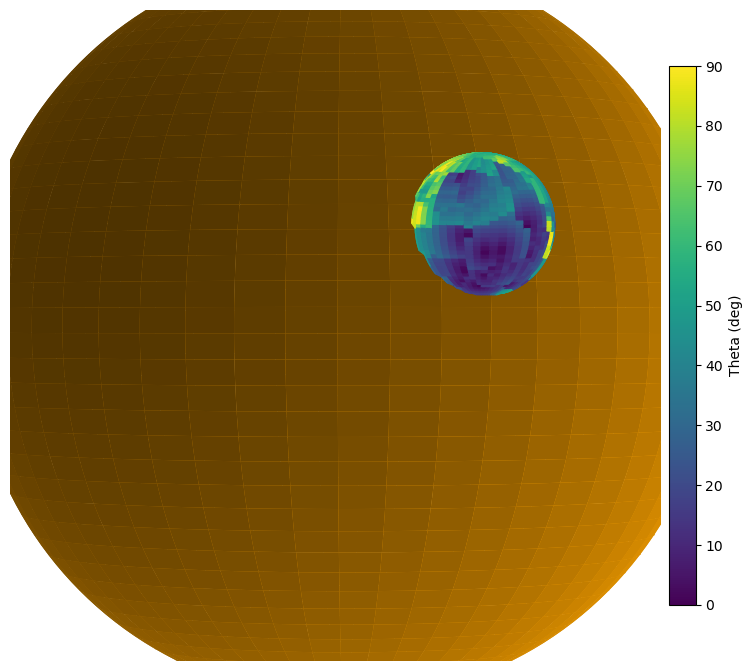

In [71]:
# Plot the 3D figure, another method
from matplotlib.colors import TwoSlopeNorm


fig = plt.figure(figsize=[10,10])
ax = fig.add_subplot(projection='3d', computed_zorder=False)
ax.plot_surface(xsun, ysun, zsun, color='orange')

norm = TwoSlopeNorm(vmin=0, vcenter=45, vmax=90)
colors = cm.get_cmap('viridis')(norm(theta))

shock = ax.plot_surface(xarr, yarr, zarr,
                        facecolors=colors,
                        shade=False
                       )

mappable = cm.ScalarMappable(norm=norm, cmap='viridis')
mappable.set_array([])
cbar = plt.colorbar(mappable, ax=ax, pad=0.01, shrink=0.7)
cbar.set_label('Theta (deg)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
limit = 0.5
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)
ax.set_box_aspect([limit, limit, limit])
ax.view_init(elev=0, azim=-90)
plt.show()